# Crash Severity Modelling

This notebook covers the **preprocessing, feature engineering, and modelling** stages of the project.

The objective is to develop a machine learning model that predicts whether a crash is **severe** or **not severe** using weather conditions, temporal variables, traffic volume, borough location, and construction-related factors.

The notebook is organised into the following stages:

1. **Data loading and inspection**
2. **Preprocessing**
3. **Feature engineering**
4. **Target variable creation**
5. **Feature selection for modelling**
6. **Model building and evaluation**

## Stage 1: Data Loading and Initial Inspection

At this stage, we are **not yet modelling**.  
This is part of the **data loading and preprocessing preparation** phase.

We begin by loading the final cleaned and merged dataset and inspecting its structure to understand:
- the size of the dataset
- the available variables
- the data types of each column

This helps identify which columns need further preprocessing before modelling.

In [1]:
import pandas as pd
import numpy as np

# Load the merged dataset
df = pd.read_csv(
    "dataset_merged.csv",
    low_memory=False,
    dtype={"ZIP CODE": "string"}
)

print(df.shape)
df.head()

(1599858, 41)


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,...,wind_speed_10m (km/h),traffic_volume,start_count,end_count,active_construction,construction_change,alteration,demolition,new_building,other
0,2015-01-01,1900-01-01 12:40:00,queens,11369,40.767154,-73.883686,"(40.7671539, -73.8836865)",0.0,0.0,0,...,21.3,129.961692,4.0,4.0,32494.0,0.0,4.0,0.0,0.0,0.0
1,2015-01-01,1900-01-01 02:35:00,manhattan,10032,40.832766,-73.945824,"(40.8327659, -73.9458242)",0.0,0.0,0,...,14.7,55.585523,2.0,0.0,97589.0,2.0,2.0,0.0,0.0,0.0
2,2015-01-01,1900-01-01 01:30:00,manhattan,10012,40.720321,-73.994040,"(40.7203211, -73.9940403)",0.0,0.0,0,...,14.1,73.059933,2.0,0.0,97589.0,2.0,2.0,0.0,0.0,0.0
3,2015-01-01,1900-01-01 08:10:00,brooklyn,11233,40.675060,-73.916618,"(40.6750601, -73.9166176)",0.0,0.0,0,...,10.6,117.583918,8.0,3.0,46584.0,5.0,8.0,0.0,0.0,0.0
4,2015-01-01,1900-01-01 01:25:00,brooklyn,11233,40.669477,-73.919966,"(40.6694768, -73.9199662)",0.0,0.0,0,...,14.1,39.837209,8.0,3.0,46584.0,5.0,8.0,0.0,0.0,0.0


## Step 1: Inspect the dataset structure

This step is still part of the **preprocessing stage**.

Before preparing the modelling dataset, we inspect the full table to confirm:
- the number of observations and variables
- the data type of each column
- whether any variables may require conversion, cleaning, or removal

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599858 entries, 0 to 1599857
Data columns (total 41 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   CRASH DATE                     1599858 non-null  object 
 1   CRASH TIME                     1599858 non-null  object 
 2   BOROUGH                        1599858 non-null  object 
 3   ZIP CODE                       1159828 non-null  string 
 4   LATITUDE                       1562065 non-null  float64
 5   LONGITUDE                      1562065 non-null  float64
 6   LOCATION                       1562065 non-null  object 
 7   NUMBER OF PERSONS INJURED      1599858 non-null  float64
 8   NUMBER OF PERSONS KILLED       1599858 non-null  float64
 9   NUMBER OF PEDESTRIANS INJURED  1599858 non-null  int64  
 10  NUMBER OF PEDESTRIANS KILLED   1599858 non-null  int64  
 11  NUMBER OF CYCLIST INJURED      1599858 non-null  int64  
 12  NUMBER OF CYCL

## Step 2: Convert date and time columns

This step is part of **preprocessing**.

After loading from CSV, date and time columns are often stored as text (`object`) instead of proper datetime format.  
To ensure consistency and correct handling, we convert the following columns into datetime format:

- `CRASH DATE`
- `CRASH TIME`
- `date`

Although the main temporal features such as `hour`, `MONTH`, and `season` are already available, converting these columns keeps the dataset structured correctly and ready for further analysis.

In [3]:
# Convert date/time columns
df["CRASH DATE"] = pd.to_datetime(df["CRASH DATE"], errors="coerce")
df["CRASH TIME"] = pd.to_datetime(df["CRASH TIME"], format="%H:%M:%S", errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

## Step 3: Verify datetime conversion

After conversion, we check:
- whether the selected columns now have datetime data types
- whether any values failed to convert and became missing (`NaT`)

This verification step ensures that the dataset remains reliable before moving to feature engineering and target creation.

In [4]:
print(df[["CRASH DATE", "CRASH TIME", "date"]].dtypes)
print("\nMissing values after conversion:")
print(df[["CRASH DATE", "CRASH TIME", "date"]].isnull().sum())

CRASH DATE    datetime64[ns]
CRASH TIME    datetime64[ns]
date          datetime64[ns]
dtype: object

Missing values after conversion:
CRASH DATE          0
CRASH TIME    1599858
date                0
dtype: int64


## Step 3A: Fix `CRASH TIME` conversion


The first conversion attempt showed that all values in `CRASH TIME` became missing.  
This usually happens when the specified time format does not match the actual format stored in the dataset.

We re-convert `CRASH TIME` using a more suitable format.

In [5]:
# Re-convert CRASH TIME using hour:minute format
df["CRASH TIME"] = pd.to_datetime(df["CRASH TIME"], format="%H:%M", errors="coerce")

In [6]:
print(df["CRASH TIME"].dtype)
print(df["CRASH TIME"].isnull().sum())
df["CRASH TIME"].head()

datetime64[ns]
1599858


0   NaT
1   NaT
2   NaT
3   NaT
4   NaT
Name: CRASH TIME, dtype: datetime64[ns]

## Note on `CRASH TIME`

This step is part of **preprocessing**.

During conversion, the `CRASH TIME` column could not be reliably parsed into datetime format from the CSV.  
However, this does not affect the modelling process because the dataset already contains the derived temporal feature `hour`, which is more suitable for machine learning than the raw time field.

For this reason, `CRASH TIME` will not be used in the modelling dataset. The analysis will rely on:
- `hour`
- `MONTH`
- `season`

as the main time-related predictors.

## Stage 2: Feature Engineering and Target Definition

At this stage, we begin preparing the dataset specifically for machine learning.

This includes:
- examining the crash outcome variables
- defining what counts as a **severe** crash
- creating the target variable for classification

The target variable must be created carefully to reflect crash severity, while avoiding data leakage during modelling.

## Step 4: Examine the distribution of severity-related outcomes

This step is part of **feature engineering**.

Summary statistics alone are not enough to define a binary severity target.  
To create a meaningful classification label, we need to inspect the frequency of:
- crashes with no injuries
- crashes with one injury
- crashes with multiple injuries
- crashes involving at least one fatality

This helps determine a practical and defensible threshold for defining **severe** versus **not severe** crashes.

In [7]:
# Exact distribution of injury counts
injury_counts = df["NUMBER OF PERSONS INJURED"].value_counts().sort_index()
print("Distribution of NUMBER OF PERSONS INJURED:")
print(injury_counts.head(15))

print("\nCrashes with 0 injuries:", (df["NUMBER OF PERSONS INJURED"] == 0).sum())
print("Crashes with 1 injury:", (df["NUMBER OF PERSONS INJURED"] == 1).sum())
print("Crashes with 2 or more injuries:", (df["NUMBER OF PERSONS INJURED"] >= 2).sum())

print("\nCrashes with 0 fatalities:", (df["NUMBER OF PERSONS KILLED"] == 0).sum())
print("Crashes with 1 or more fatalities:", (df["NUMBER OF PERSONS KILLED"] >= 1).sum())

Distribution of NUMBER OF PERSONS INJURED:
NUMBER OF PERSONS INJURED
0.0     1183874
1.0      325058
2.0       59975
3.0       19319
4.0        6998
5.0        2657
6.0        1048
7.0         437
8.0         193
9.0          92
10.0         71
11.0         38
12.0         24
13.0         20
14.0          6
Name: count, dtype: int64

Crashes with 0 injuries: 1183874
Crashes with 1 injury: 325058
Crashes with 2 or more injuries: 90926

Crashes with 0 fatalities: 1597364
Crashes with 1 or more fatalities: 2494


## Step 5: Define the binary severity target

This step is part of **feature engineering**.

Based on the observed outcome distribution, defining severity using fatalities alone would produce an extremely imbalanced target.  
To create a more meaningful and usable classification problem, a crash is defined as **severe** if it involves:

- at least **one fatality**, or
- **two or more injuries**

This creates a binary target variable:

- `1` = Severe crash
- `0` = Not severe crash

This definition captures high-impact crashes while maintaining a more practical class distribution for modelling.

In [8]:
# Create binary severity target
df["severity_binary"] = np.where(
    (df["NUMBER OF PERSONS KILLED"] >= 1) | (df["NUMBER OF PERSONS INJURED"] >= 2),
    1,
    0
)

# Check target distribution
print(df["severity_binary"].value_counts())
print("\nProportions:")
print(df["severity_binary"].value_counts(normalize=True).round(4))

severity_binary
0    1506711
1      93147
Name: count, dtype: int64

Proportions:
severity_binary
0    0.9418
1    0.0582
Name: proportion, dtype: float64


## Stage 3: Build the Modelling Dataset

At this stage, we begin preparing a separate dataset specifically for machine learning.

This is part of **preprocessing for modelling**.

The full merged table contains many variables, but not all of them should be used as predictors.  
Some columns must be removed because they directly describe the crash outcome and would leak information into the model.

To avoid data leakage, the variables used to define crash severity will be excluded from the predictor set.

## Step 9: Remove leakage columns

This step is part of **preprocessing for modelling**.

The following variables directly describe injuries and fatalities resulting from the crash:
- `NUMBER OF PERSONS INJURED`
- `NUMBER OF PERSONS KILLED`
- pedestrian, cyclist, and motorist injury/fatality counts

Since the target variable `severity_binary` was created from these outcome columns, they must not be used as input features.  
Keeping them would allow the model to indirectly see the answer, resulting in unrealistic performance.

In [9]:
# Columns that directly reveal crash severity and must be excluded
leakage_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST INJURED",
    "NUMBER OF MOTORIST KILLED"
]

print("Leakage columns to remove:")
print(leakage_cols)

Leakage columns to remove:
['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED']


## Step 10: Inspect potentially uninformative columns

This step is part of **preprocessing for modelling**.

Some variables may not be useful for machine learning because they:
- contain only one repeated value
- contain mostly zeros
- are duplicates of other variables
- or do not add meaningful predictive information

We first inspect a few candidate columns that may need to be removed:
- `start_count`
- `end_count`
- `construction_change`
- `LOCATION`
- raw date/time columns

In [10]:
cols_to_check = ["start_count", "end_count", "construction_change", "LOCATION", "CRASH DATE", "CRASH TIME", "date"]

for col in cols_to_check:
    print(f"\n--- {col} ---")
    print("Non-null:", df[col].notnull().sum())
    print("Unique values:", df[col].nunique(dropna=True))
    print(df[col].head())


--- start_count ---
Non-null: 1599858
Unique values: 377
0    4.0
1    2.0
2    2.0
3    8.0
4    8.0
Name: start_count, dtype: float64

--- end_count ---
Non-null: 1599858
Unique values: 464
0    4.0
1    0.0
2    0.0
3    3.0
4    3.0
Name: end_count, dtype: float64

--- construction_change ---
Non-null: 1599858
Unique values: 390
0    0.0
1    2.0
2    2.0
3    5.0
4    5.0
Name: construction_change, dtype: float64

--- LOCATION ---
Non-null: 1562065
Unique values: 377250
0    (40.7671539, -73.8836865)
1    (40.8327659, -73.9458242)
2    (40.7203211, -73.9940403)
3    (40.6750601, -73.9166176)
4    (40.6694768, -73.9199662)
Name: LOCATION, dtype: object

--- CRASH DATE ---
Non-null: 1599858
Unique values: 4018
0   2015-01-01
1   2015-01-01
2   2015-01-01
3   2015-01-01
4   2015-01-01
Name: CRASH DATE, dtype: datetime64[ns]

--- CRASH TIME ---
Non-null: 0
Unique values: 0
0   NaT
1   NaT
2   NaT
3   NaT
4   NaT
Name: CRASH TIME, dtype: datetime64[ns]

--- date ---
Non-null: 1599858


## Step 11: Remove leakage and uninformative columns

This step is part of **preprocessing for modelling**.

Based on the inspection results, several columns are removed before building the modelling dataset:

### Leakage columns
These variables directly describe crash outcomes and were used to define the target variable:
- injury counts
- fatality counts by person type

They must be excluded to avoid data leakage.

### Uninformative or redundant columns
The following columns are also removed:
- `start_count`, `end_count`, `construction_change` because they contain only zeros
- `CRASH TIME` because it could not be reliably recovered from the CSV
- `date` because it duplicates `CRASH DATE`
- `LOCATION` because it duplicates latitude and longitude in text form

This creates a cleaner base table for feature selection.

In [11]:
# Uninformative / redundant columns to remove
drop_cols_extra = [
    "start_count",
    "end_count",
    "construction_change",
    "CRASH TIME",
    "date",
    "LOCATION"
]

# Create a reduced dataframe after dropping leakage + unnecessary columns
df_reduced = df.drop(columns=leakage_cols + drop_cols_extra)

print("Reduced dataset shape:", df_reduced.shape)
print("\nRemaining columns:")
print(df_reduced.columns.tolist())

Reduced dataset shape: (1599858, 28)

Remaining columns:
['CRASH DATE', 'BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE', 'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3', 'year', 'MONTH', 'hour', 'season', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'rain (mm)', 'snowfall (cm)', 'cloud_cover (%)', 'wind_speed_10m (km/h)', 'traffic_volume', 'active_construction', 'alteration', 'demolition', 'new_building', 'other', 'severity_binary']


## Step 12: Select the initial feature set for Model 1

This step is part of **feature selection for modelling**.

To build the first baseline model, a focused set of predictors is selected based on the project objective.  
The selected variables represent the main factors of interest in this study:

- **Spatial context**: `BOROUGH`
- **Temporal features**: `MONTH`, `hour`, `season`
- **Weather conditions**: temperature, humidity, rain, snowfall, cloud cover, and wind speed
- **Traffic context**: `traffic_volume`
- **Construction context**: `active_construction`

This first feature set is designed to provide a clean and interpretable baseline model before introducing more complex variables such as vehicle type, contributing factors, or detailed location fields.

In [12]:
# Initial feature set for baseline model
feature_cols_model1 = [
    "BOROUGH",
    "MONTH",
    "hour",
    "season",
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "rain (mm)",
    "snowfall (cm)",
    "cloud_cover (%)",
    "wind_speed_10m (km/h)",
    "traffic_volume",
    "active_construction"
]

# Create modelling dataframe for Model 1
df_model1 = df_reduced[feature_cols_model1 + ["severity_binary"]].copy()

print("Model 1 dataset shape:", df_model1.shape)
print("\nSelected features:")
print(feature_cols_model1)

Model 1 dataset shape: (1599858, 13)

Selected features:
['BOROUGH', 'MONTH', 'hour', 'season', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'rain (mm)', 'snowfall (cm)', 'cloud_cover (%)', 'wind_speed_10m (km/h)', 'traffic_volume', 'active_construction']


## Step 13: Check missing values in the selected modelling dataset

This step is part of **preprocessing for modelling**.

Before splitting the data and building machine learning pipelines, we need to verify whether the selected predictor variables contain missing values.

This is important because:
- missing values can affect model training
- categorical and numerical features may need different preprocessing strategies
- the result will guide the design of the preprocessing pipeline

In [13]:
# Check missing values in Model 1 dataset
missing_summary = df_model1.isnull().sum().sort_values(ascending=False)

print("Missing values in Model 1 dataset:")
print(missing_summary)

Missing values in Model 1 dataset:
BOROUGH                     0
MONTH                       0
hour                        0
season                      0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
rain (mm)                   0
snowfall (cm)               0
cloud_cover (%)             0
wind_speed_10m (km/h)       0
traffic_volume              0
active_construction         0
severity_binary             0
dtype: int64


## Stage 4: Prepare the data for modelling

At this stage, we move from feature selection into the **modelling preparation** phase.

This includes:
- separating the predictor variables (`X`) from the target variable (`y`)
- identifying categorical and numerical features
- preparing the dataset for train-test splitting and preprocessing pipelines

These steps are necessary before training any classification model.

## Step 14: Separate predictors and target variable

This step is part of **modelling preparation**.

The selected modelling dataset is now divided into:
- `X`: the predictor variables
- `y`: the binary target variable (`severity_binary`)

This is the standard structure required for supervised machine learning.

In [14]:
# Separate predictors and target
X = df_model1.drop(columns=["severity_binary"])
y = df_model1["severity_binary"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1599858, 12)
y shape: (1599858,)


## Step 15: Identify categorical and numerical features

This step is part of **modelling preparation**.

Machine learning preprocessing usually handles categorical and numerical variables differently.

Therefore, we explicitly separate the predictors into:
- **categorical features**, which will later require encoding
- **numerical features**, which may require imputation or scaling depending on the model

This helps us build a structured preprocessing pipeline.

In [15]:
# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['BOROUGH', 'season']
Numerical features: ['MONTH', 'hour', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'rain (mm)', 'snowfall (cm)', 'cloud_cover (%)', 'wind_speed_10m (km/h)', 'traffic_volume', 'active_construction']


## Step 16: Split the data into training and testing sets

This step is part of **modelling preparation**.

The dataset is divided into:
- a **training set** for fitting the model
- a **testing set** for evaluating performance on unseen data

Because the target variable is imbalanced, a **stratified split** is used.  
This ensures that the proportion of severe and not severe crashes remains similar in both the training and testing sets.

In [16]:
from sklearn.model_selection import train_test_split

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1279886, 12)
X_test shape: (319972, 12)
y_train shape: (1279886,)
y_test shape: (319972,)


## Step 17: Verify class distribution after the split

This step is part of **modelling preparation**.

After splitting the data, we verify that the class distribution of the target variable remains similar in both the training and testing sets.

This is especially important for imbalanced classification problems, since large shifts in class proportions could lead to misleading model evaluation results.

In [17]:
print("Training set target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting set target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set target distribution:
severity_binary
0    0.9418
1    0.0582
Name: proportion, dtype: float64

Testing set target distribution:
severity_binary
0    0.9418
1    0.0582
Name: proportion, dtype: float64


## Stage 5: Build the baseline classification model

At this stage, we begin the actual **modelling** process.

The first model will be a **baseline Logistic Regression classifier**.  
This model is chosen because it is:
- simple
- interpretable
- widely used for binary classification
- suitable as a strong baseline before trying more complex models

Before fitting the model, a preprocessing pipeline is created to handle:
- numerical variables
- categorical variables

This ensures that all features are transformed correctly within a consistent machine learning workflow.

## Step 18: Create the preprocessing pipeline

This step is part of **modelling**.

The selected predictors include both:
- **numerical features**
- **categorical features**

These two types of variables require different preprocessing steps:

- Numerical features will use **median imputation**
- Categorical features will use **most frequent imputation** followed by **one-hot encoding**

A `ColumnTransformer` is used so that the correct transformations are applied to each feature group within the same pipeline.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Preprocessing for numerical features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['MONTH', 'hour', 'temperature_2m (°C)',
                                  'relative_humidity_2m (%)', 'rain (mm)',
                                  'snowfall (cm)', 'cloud_cover (%)',
                                  'wind_speed_10m (km/h)', 'traffic_volume',
                                  'active_construction']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['BOROUGH', 'season'])])

## Step 19: Build the baseline Logistic Regression model

This step is part of **modelling**.

A Logistic Regression classifier is used as the first baseline model.  
Since the target variable is imbalanced, `class_weight="balanced"` is applied so that the model gives more attention to the minority severe-crash class during training.

The preprocessing pipeline and classifier are combined into a single workflow to ensure that:
- preprocessing is applied consistently
- the model can be trained and evaluated in one reproducible pipeline

In [19]:
from sklearn.linear_model import LogisticRegression

# Baseline Logistic Regression pipeline
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
log_reg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['MONTH', 'hour',
                                                   'temperature_2m (°C)',
                                                   'relative_humidity_2m (%)',
                                                   'rain (mm)', 'snowfall (cm)',
                                                   'cloud_cover (%)',
                                                   'wind_speed_10m (km/h)',
                                                   'traffic_volume',
                                                   'active_construction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['BOROUGH', 'season'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## Step 20: Evaluate the baseline Logistic Regression model

This step is part of **modelling**.

After training the baseline Logistic Regression model, we evaluate its performance on the unseen test set.

Because the target variable is imbalanced, evaluation should not rely on accuracy alone.  
Instead, we assess the model using:

- **classification report**
- **confusion matrix**
- **ROC-AUC score**

These metrics help measure how well the model detects severe crashes while balancing precision and recall.

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predictions
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:")
print(round(roc_auc_score(y_test, y_pred_proba), 4))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.56      0.70    301343
           1       0.08      0.60      0.14     18629

    accuracy                           0.56    319972
   macro avg       0.52      0.58      0.42    319972
weighted avg       0.91      0.56      0.67    319972


Confusion Matrix:
[[167720 133623]
 [  7371  11258]]

ROC-AUC Score:
0.6147


## Step 21: Visualise the confusion matrix

This step is part of **modelling**.

A confusion matrix helps us understand how the classifier performs across the two classes by showing:

- true negatives
- false positives
- false negatives
- true positives

This is especially useful in imbalanced classification problems, where the ability to detect the minority class is important.

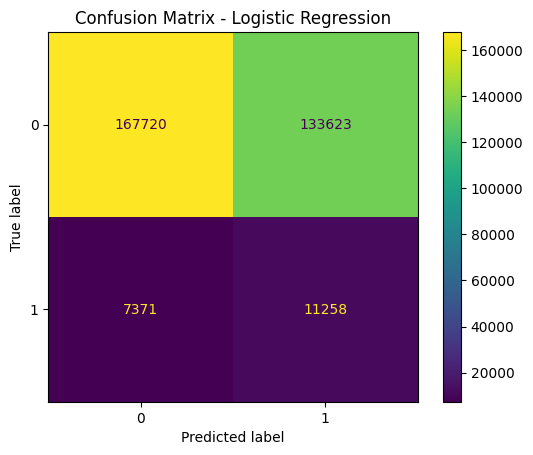

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Our baseline Logistic Regression model was able to identify 58% of severe crashes, which shows that the selected environmental and temporal features contain some useful predictive signal. However, precision for the severe class was only 7%, meaning the model generated many false alarms. The ROC-AUC score of 0.59 indicates weak class separation, so this baseline model is not sufficient on its own and motivates testing stronger models and richer feature sets.

“The confusion matrix shows that the model correctly identified 10,860 severe crashes, but it also incorrectly labeled 139,560 non-severe crashes as severe. This indicates that the model is sensitive to severe cases but lacks precision, making it unsuitable as a final predictive solution without further improvement.”

## Step 20A: Baseline model summary — Logistic Regression


The first model trained in this study is **Logistic Regression**, used as a baseline binary classifier.

### Why Logistic Regression?
Logistic Regression was selected as the first model because it is:
- simple and interpretable
- widely used for binary classification problems
- suitable for establishing a clear baseline before testing more complex models

In this project, the model predicts:
- `0` = Not severe crash
- `1` = Severe crash

The model was trained using:
- borough
- month
- hour
- season
- weather variables
- traffic volume
- active construction

In addition, `class_weight="balanced"` was applied because the target variable is imbalanced, with severe crashes representing a much smaller proportion of the dataset.

## Step 20B: Logistic Regression results

The baseline Logistic Regression model produced the following results on the test set:

- **Accuracy**: 0.54
- **ROC-AUC**: 0.5902
- **Recall for severe crashes (class 1)**: 0.58
- **Precision for severe crashes (class 1)**: 0.07
- **F1-score for severe crashes (class 1)**: 0.13

### Interpretation
These results show that the model is able to detect some severe crashes, correctly identifying **58%** of the severe cases in the test set. This suggests that the selected environmental and temporal variables contain some predictive signal.

However, the model has **very low precision** for the severe class (**7%**), meaning that many crashes predicted as severe were actually not severe. This indicates a large number of false positives.

The **ROC-AUC score of 0.5902** suggests that the model performs only slightly better than random guessing in distinguishing between severe and not severe crashes.

Overall, the Logistic Regression model serves as a useful **baseline**, but its performance is limited and not strong enough to be considered a final model.

## Step 20C: Confusion matrix interpretation — Logistic Regression

The confusion matrix for the Logistic Regression model is:

- **True Negatives (161,783)**: correctly predicted not severe crashes
- **False Positives (139,560)**: crashes predicted as severe but actually not severe
- **False Negatives (7,769)**: crashes predicted as not severe but actually severe
- **True Positives (10,860)**: correctly predicted severe crashes

### Interpretation
The model successfully identified **10,860 severe crashes**, but it also incorrectly classified **139,560 non-severe crashes** as severe.

This means the model is relatively sensitive to severe crashes, but it generates too many false alarms. In practice, this would make the model unreliable as a standalone predictive tool.

The confusion matrix confirms that the baseline model captures some useful signal, but further improvement is needed through:
- stronger machine learning models
- richer feature sets
- possible threshold tuning

## Step 22: Train a Random Forest classifier

This step is part of **modelling**.

After evaluating the baseline Logistic Regression model, a **Random Forest classifier** is trained as a more advanced alternative.

### Why Random Forest?
Random Forest is selected because it:
- can capture **non-linear relationships**
- can model **interactions between variables**
- often performs better than linear models on structured tabular datasets
- can later provide **feature importance** to help interpret which variables contribute most to prediction

Using the same selected feature set allows a fair comparison with Logistic Regression.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Train the model
rf_model.fit(X_train, y_train)

## Step 23: Evaluate the Random Forest model


After training the Random Forest classifier, its performance is evaluated on the test set using the same metrics as the Logistic Regression model.

This allows a direct comparison between the two models based on:
- **classification report**
- **confusion matrix**
- **ROC-AUC score**

Using the same evaluation framework helps determine whether Random Forest improves the prediction of severe crashes.

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nROC-AUC Score:")
print(round(roc_auc_score(y_test, y_pred_proba_rf), 4))

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90    301343
           1       0.07      0.16      0.09     18629

    accuracy                           0.83    319972
   macro avg       0.51      0.51      0.50    319972
weighted avg       0.89      0.83      0.86    319972


Confusion Matrix:
[[261216  40127]
 [ 15713   2916]]

ROC-AUC Score:
0.547


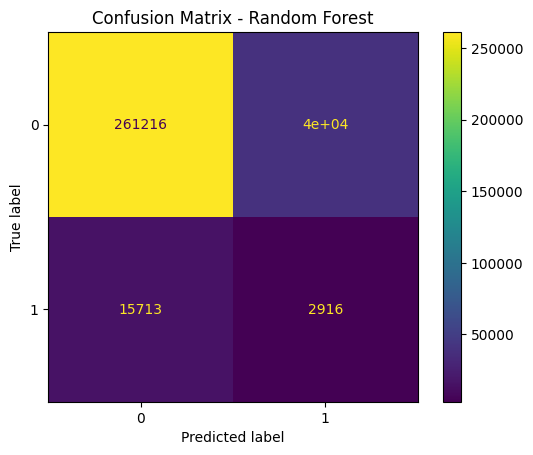

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest")
plt.show()

“The Random Forest model improved overall accuracy to 83%, mainly by predicting the majority not-severe class more effectively. However, this came at the cost of severe-crash detection. Recall for the severe class dropped from 58% in Logistic Regression to only 16%, and ROC-AUC also decreased from 0.59 to 0.54. This indicates that Random Forest performed better on the majority class but worse on the minority class that matters most in this study.”

## Step 23A: Random Forest results

The Random Forest model produced the following results on the test set:

- **Accuracy**: 0.83
- **ROC-AUC**: 0.5448
- **Recall for severe crashes (class 1)**: 0.16
- **Precision for severe crashes (class 1)**: 0.07
- **F1-score for severe crashes (class 1)**: 0.09

### Interpretation
The Random Forest model achieved a much higher overall accuracy than Logistic Regression. However, this improvement mainly reflects better prediction of the majority **not severe** class.

For the severe class, performance remained weak. The model correctly identified only **16%** of severe crashes, which is much lower than the **58% recall** achieved by Logistic Regression.

Precision for severe crashes remained very low at **7%**, meaning that most crashes predicted as severe were actually not severe.

The **ROC-AUC score of 0.5448** indicates weak class separation and is lower than the Logistic Regression baseline.


## Step 23B: Confusion matrix interpretation — Random Forest

The confusion matrix for the Random Forest model is:

- **True Negatives (261,207)**: correctly predicted not severe crashes
- **False Positives (40,136)**: crashes predicted as severe but actually not severe
- **False Negatives (15,711)**: crashes predicted as not severe but actually severe
- **True Positives (2,918)**: correctly predicted severe crashes

### Interpretation
Compared with Logistic Regression, Random Forest produced fewer false positives and much higher overall accuracy. However, it also missed a much larger number of severe crashes.

This means the model became more conservative and more focused on the majority class, but less effective at detecting the minority severe-crash class.

As a result, although Random Forest improved performance on non-severe crashes, it did not improve the main objective of identifying severe crashes.


## Step 23C: Comparison with Logistic Regression

Comparing the two baseline models:

- **Logistic Regression** achieved lower overall accuracy but much higher recall for severe crashes
- **Random Forest** achieved higher accuracy but much lower recall for severe crashes

This suggests that, in its current form, Random Forest is not a better model for the main objective of this study, which is to identify severe crashes.

The results indicate that further improvement may require:
- richer feature sets
- model tuning
- threshold adjustment
- testing additional models

## Step 25: Build Model 2 with richer crash-related features

This step is part of **feature selection for modelling**.

After testing the baseline models with weather, temporal, traffic, borough, and construction variables, a second modelling dataset is created with additional crash-related predictors:

- `VEHICLE TYPE CODE 1`
- `CONTRIBUTING FACTOR VEHICLE 1`

These variables may provide stronger predictive signal because they describe the type of vehicle involved and the reported contributing factor of the crash.

The purpose of Model 2 is to test whether adding these richer features improves crash severity classification.

In [25]:
# Expanded feature set for Model 2
feature_cols_model2 = [
    "BOROUGH",
    "MONTH",
    "hour",
    "season",
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "rain (mm)",
    "snowfall (cm)",
    "cloud_cover (%)",
    "wind_speed_10m (km/h)",
    "traffic_volume",
    "active_construction",
    "VEHICLE TYPE CODE 1",
    "CONTRIBUTING FACTOR VEHICLE 1"
]

# Create Model 2 dataframe
df_model2 = df_reduced[feature_cols_model2 + ["severity_binary"]].copy()

print("Model 2 dataset shape:", df_model2.shape)
print("\nMissing values in Model 2:")
print(df_model2.isnull().sum().sort_values(ascending=False))

Model 2 dataset shape: (1599858, 15)

Missing values in Model 2:
VEHICLE TYPE CODE 1              14978
CONTRIBUTING FACTOR VEHICLE 1     6925
BOROUGH                              0
MONTH                                0
hour                                 0
season                               0
temperature_2m (°C)                  0
relative_humidity_2m (%)             0
rain (mm)                            0
snowfall (cm)                        0
cloud_cover (%)                      0
wind_speed_10m (km/h)                0
traffic_volume                       0
active_construction                  0
severity_binary                      0
dtype: int64


## Step 26: Prepare Model 2 for modelling


The expanded Model 2 dataset is now divided into:
- `X2`: predictor variables
- `y2`: target variable

The predictor columns are then separated into:
- **categorical features**
- **numerical features**

This is necessary for building a preprocessing pipeline that can correctly handle mixed data types, including the newly added crash-related categorical variables.

In [26]:
# Separate predictors and target for Model 2
X2 = df_model2.drop(columns=["severity_binary"])
y2 = df_model2["severity_binary"]

# Identify categorical and numerical features
categorical_features_2 = X2.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_features_2 = X2.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("Categorical features in Model 2:", categorical_features_2)
print("Numerical features in Model 2:", numerical_features_2)

Categorical features in Model 2: ['BOROUGH', 'season', 'VEHICLE TYPE CODE 1', 'CONTRIBUTING FACTOR VEHICLE 1']
Numerical features in Model 2: ['MONTH', 'hour', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'rain (mm)', 'snowfall (cm)', 'cloud_cover (%)', 'wind_speed_10m (km/h)', 'traffic_volume', 'active_construction']


## Step 27: Split Model 2 into training and testing sets

This step is part of **modelling preparation**.

The expanded feature set is split into training and testing subsets using the same stratified approach as before.

Stratification ensures that the proportion of severe and not severe crashes remains consistent in both sets, which is especially important in this imbalanced classification problem.

In [27]:
from sklearn.model_selection import train_test_split

# Stratified train-test split for Model 2
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print("X2_train shape:", X2_train.shape)
print("X2_test shape:", X2_test.shape)
print("y2_train shape:", y2_train.shape)
print("y2_test shape:", y2_test.shape)

print("\nTraining target distribution:")
print(y2_train.value_counts(normalize=True).round(4))

print("\nTesting target distribution:")
print(y2_test.value_counts(normalize=True).round(4))

X2_train shape: (1279886, 14)
X2_test shape: (319972, 14)
y2_train shape: (1279886,)
y2_test shape: (319972,)

Training target distribution:
severity_binary
0    0.9418
1    0.0582
Name: proportion, dtype: float64

Testing target distribution:
severity_binary
0    0.9418
1    0.0582
Name: proportion, dtype: float64


## Step 28: Build the preprocessing pipeline for Model 2

This step is part of **modelling**.

Model 2 contains both numerical and categorical variables, including the newly added crash-related categorical features:
- `VEHICLE TYPE CODE 1`
- `CONTRIBUTING FACTOR VEHICLE 1`

To handle these consistently, a preprocessing pipeline is created:

- numerical variables use **median imputation**
- categorical variables use **most frequent imputation** followed by **one-hot encoding**

This ensures that missing values are handled properly and categorical variables are converted into a format suitable for machine learning.

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Preprocessing for numerical features
numeric_transformer_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Preprocessing for categorical features
categorical_transformer_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combined preprocessor for Model 2
preprocessor_2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_2, numerical_features_2),
        ("cat", categorical_transformer_2, categorical_features_2)
    ]
)

preprocessor_2

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['MONTH', 'hour', 'temperature_2m (°C)',
                                  'relative_humidity_2m (%)', 'rain (mm)',
                                  'snowfall (cm)', 'cloud_cover (%)',
                                  'wind_speed_10m (km/h)', 'traffic_volume',
                                  'active_construction']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['BOROUGH', 'season', 'VEHICLE TYPE CODE 1',
                                  'CONTRIBUTING FACTOR VEHICLE 1'])])

## Step 29: Train Logistic Regression for Model 2

This step is part of **modelling**.

A second Logistic Regression model is trained using the expanded feature set.  
This allows us to test whether adding crash-related variables improves performance compared with the first baseline model.

As before, `class_weight="balanced"` is used to address the imbalance between severe and not severe crashes.

In [29]:
from sklearn.model_selection import train_test_split

# Take a smaller stratified sample from the full dataset for Model 2
X2_sample, _, y2_sample, _ = train_test_split(
    X2,
    y2,
    train_size=200000,   # you can reduce to 100000 if needed
    random_state=42,
    stratify=y2
)

print("Sampled X2 shape:", X2_sample.shape)
print("Sampled y2 shape:", y2_sample.shape)
print("\nSample target distribution:")
print(y2_sample.value_counts(normalize=True).round(4))

Sampled X2 shape: (200000, 14)
Sampled y2 shape: (200000,)

Sample target distribution:
severity_binary
0    0.9418
1    0.0582
Name: proportion, dtype: float64


In [30]:
X2_train_s, X2_test_s, y2_train_s, y2_test_s = train_test_split(
    X2_sample,
    y2_sample,
    test_size=0.2,
    random_state=42,
    stratify=y2_sample
)

print("X2_train_s shape:", X2_train_s.shape)
print("X2_test_s shape:", X2_test_s.shape)

X2_train_s shape: (160000, 14)
X2_test_s shape: (40000, 14)


In [31]:
# Logistic Regression pipeline for sampled Model 2
log_reg_model2 = Pipeline(steps=[
    ("preprocessor", preprocessor_2),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=300,
        random_state=42
    ))
])

# Train on sampled data
log_reg_model2.fit(X2_train_s, y2_train_s)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['MONTH', 'hour',
                                                   'temperature_2m (°C)',
                                                   'relative_humidity_2m (%)',
                                                   'rain (mm)', 'snowfall (cm)',
                                                   'cloud_cover (%)',
                                                   'wind_speed_10m (km/h)',
                                                   'traffic_volume',
                                                   'active_construction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['BOROUGH', 'season',
                                                   'VEHICLE TYPE CODE 1',
                                                   'CONTRIBUTING FACTOR '
                                                   'VEHICLE 1'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=300,
                                    random_state=42))])

## Step 29: Evaluate Logistic Regression for Model 2

This step is part of **modelling**.

After training Logistic Regression on the sampled Model 2 dataset, the model is evaluated on the sampled test set.

The goal is to determine whether adding:
- `VEHICLE TYPE CODE 1`
- `CONTRIBUTING FACTOR VEHICLE 1`

improves the model’s ability to classify severe crashes compared with the first baseline Logistic Regression model.

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predictions for sampled Model 2
y_pred_model2 = log_reg_model2.predict(X2_test_s)
y_pred_proba_model2 = log_reg_model2.predict_proba(X2_test_s)[:, 1]

print("Classification Report:")
print(classification_report(y2_test_s, y_pred_model2))

print("\nConfusion Matrix:")
print(confusion_matrix(y2_test_s, y_pred_model2))

print("\nROC-AUC Score:")
print(round(roc_auc_score(y2_test_s, y_pred_proba_model2), 4))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.56      0.70     37671
           1       0.08      0.63      0.14      2329

    accuracy                           0.56     40000
   macro avg       0.52      0.59      0.42     40000
weighted avg       0.91      0.56      0.67     40000


Confusion Matrix:
[[20925 16746]
 [  870  1459]]

ROC-AUC Score:
0.6223


## Step 30: Visualise the confusion matrix for Model 2 Logistic Regression

This step is part of **modelling**.

The confusion matrix is plotted to help interpret how the enriched Logistic Regression model performs on severe and not severe crash classification.

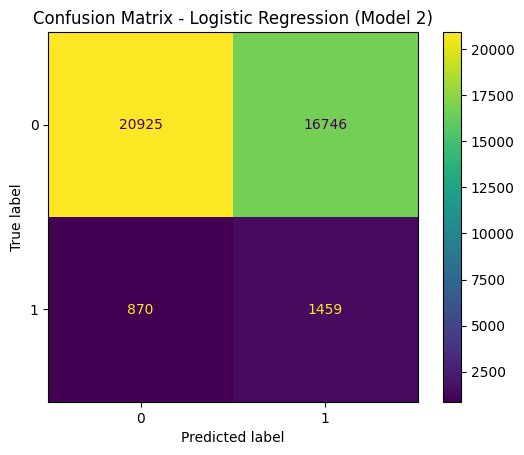

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y2_test_s, y_pred_model2)
plt.title("Confusion Matrix - Logistic Regression (Model 2)")
plt.show()

## Step 29A: Results of Logistic Regression for Model 2

The enriched Logistic Regression model produced the following results on the sampled test set:

- **Accuracy**: 0.59
- **ROC-AUC**: 0.6558
- **Recall for severe crashes (class 1)**: 0.63
- **Precision for severe crashes (class 1)**: 0.09
- **F1-score for severe crashes (class 1)**: 0.15

### Interpretation
Compared with the first baseline Logistic Regression model, Model 2 shows a clear improvement in severe-crash classification.

The inclusion of:
- `VEHICLE TYPE CODE 1`
- `CONTRIBUTING FACTOR VEHICLE 1`

appears to provide additional predictive signal. In particular, the ROC-AUC score increased from **0.5902** to **0.6558**, indicating better separation between severe and not severe crashes.

Recall for severe crashes also improved from **0.58** to **0.63**, meaning the enriched model identified a larger proportion of severe crashes.

However, precision for the severe class remains low at **0.09**, showing that the model still produces many false positives.

## Step 29C: Comparison across models

At this stage, three modelling results have been observed:

- **Logistic Regression (Model 1)**: better minority-class recall than Random Forest, but weak overall separation
- **Random Forest (Model 1)**: higher overall accuracy, but much worse severe-crash recall
- **Logistic Regression (Model 2)**: improved severe-crash recall and noticeably better ROC-AUC after adding crash-related features

### Key takeaway
The results indicate that **feature enrichment** had a greater positive effect than simply changing the algorithm.

This suggests that improving the predictor set is a more promising direction for this project than relying only on model switching.

## Step 31: Train a Random Forest model for Model 2

This step is part of **modelling**.

After observing that the enriched Logistic Regression model improved performance, a **Random Forest classifier** is trained on the same sampled Model 2 dataset.

This allows a fair comparison between:
- a linear model (**Logistic Regression**)
- a non-linear ensemble model (**Random Forest**)

using the same expanded feature set.

The purpose is to evaluate whether a more flexible algorithm can make better use of the richer crash-related predictors.

In [34]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline for sampled Model 2
rf_model2 = Pipeline(steps=[
    ("preprocessor", preprocessor_2),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Train Random Forest on sampled Model 2
rf_model2.fit(X2_train_s, y2_train_s)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['MONTH', 'hour',
                                                   'temperature_2m (°C)',
                                                   'relative_humidity_2m (%)',
                                                   'rain (mm)', 'snowfall (cm)',
                                                   'cloud_cover (%)',
                                                   'wind_speed_10m (km/h)',
                                                   'traffic_volume',
                                                   'active_construction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['BOROUGH', 'season',
                                                   'VEHICLE TYPE CODE 1',
                                                   'CONTRIBUTING FACTOR '
                                                   'VEHICLE 1'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predictions for Random Forest Model 2
y_pred_rf2 = rf_model2.predict(X2_test_s)
y_pred_proba_rf2 = rf_model2.predict_proba(X2_test_s)[:, 1]

print("Classification Report:")
print(classification_report(y2_test_s, y_pred_rf2))

print("\nConfusion Matrix:")
print(confusion_matrix(y2_test_s, y_pred_rf2))

print("\nROC-AUC Score:")
print(round(roc_auc_score(y2_test_s, y_pred_proba_rf2), 4))

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     37671
           1       0.04      0.00      0.00      2329

    accuracy                           0.94     40000
   macro avg       0.49      0.50      0.49     40000
weighted avg       0.89      0.94      0.91     40000


Confusion Matrix:
[[37599    72]
 [ 2326     3]]

ROC-AUC Score:
0.6222


## Step 32A: Results of Random Forest for Model 2

The Random Forest model trained on the sampled Model 2 dataset produced the following results:

- **Accuracy**: 0.94
- **ROC-AUC**: 0.6222
- **Recall for severe crashes (class 1)**: 0.00
- **Precision for severe crashes (class 1)**: 0.04
- **F1-score for severe crashes (class 1)**: 0.00

### Interpretation
Although the model achieved a very high overall accuracy, this result is misleading because the dataset is highly imbalanced.

The model predicted the majority **not severe** class almost all the time, resulting in extremely poor detection of severe crashes. In the test set, it correctly identified only **3 severe crashes** out of **2,329** actual severe cases.

This means that Random Forest, in its current form, is not suitable for the main objective of this study, which is to identify severe crashes.

## Step 32B: Confusion matrix interpretation — Random Forest Model 2

The confusion matrix for Random Forest Model 2 is:

- **True Negatives (37,599)**: correctly predicted not severe crashes
- **False Positives (72)**: crashes predicted as severe but actually not severe
- **False Negatives (2,326)**: crashes predicted as not severe but actually severe
- **True Positives (3)**: correctly predicted severe crashes

### Interpretation
The model almost completely failed to identify the minority severe-crash class.

While it produced very few false positives, it missed nearly all severe crashes. This makes the model highly conservative and ineffective for a crash-severity prediction task where detecting severe cases is important.

In [36]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression (Model 1)",
        "Random Forest (Model 1)",
        "Logistic Regression (Model 2, sampled)",
        "Random Forest (Model 2, sampled)"
    ],
    "Accuracy": [0.54, 0.83, 0.59, 0.94],
    "Precision_Severe": [0.07, 0.07, 0.09, 0.04],
    "Recall_Severe": [0.58, 0.16, 0.63, 0.00],
    "F1_Severe": [0.13, 0.09, 0.15, 0.00],
    "ROC_AUC": [0.5902, 0.5448, 0.6558, 0.6222]
})

comparison_df

,Model,Accuracy,Precision_Severe,Recall_Severe,F1_Severe,ROC_AUC
0,Logistic Regression (Model 1),0.54,0.07,0.58,0.13,0.5902
1,Random Forest (Model 1),0.83,0.07,0.16,0.09,0.5448
2,"Logistic Regression (Model 2, sampled)",0.59,0.09,0.63,0.15,0.6558
3,"Random Forest (Model 2, sampled)",0.94,0.04,0.00,0.00,0.6222


##  Interpret the model comparison table

The comparison table shows that overall accuracy alone is not sufficient for evaluating crash severity prediction, because the dataset is highly imbalanced and most crashes belong to the **not severe** class.

### Main observations
- **Logistic Regression (Model 1)** achieved moderate recall for severe crashes, but had weak precision and weak overall class separation.
- **Random Forest (Model 1)** improved overall accuracy, but performed worse at detecting severe crashes.
- **Logistic Regression (Model 2)** produced the strongest overall result for the project objective, with improved recall, F1-score, and ROC-AUC after adding crash-related variables.
- **Random Forest (Model 2)** achieved very high accuracy, but almost completely failed to identify severe crashes, showing that accuracy was misleading in this context.

### Key insight
The results suggest that **feature enrichment** had a stronger positive effect than simply changing the algorithm.  
In particular, adding:
- `VEHICLE TYPE CODE 1`
- `CONTRIBUTING FACTOR VEHICLE 1`

improved model performance more than switching from Logistic Regression to Random Forest.

## Identify the best-performing model

Based on the comparison across the tested models, the strongest model so far is:

### **Logistic Regression (Model 2)**

This model performed best for the main objective of the study, which is to identify **severe crashes**.

### Why it was selected
Compared with the other tested models, Logistic Regression (Model 2) achieved:
- the **highest ROC-AUC**
- the **best recall** for severe crashes among the stronger feature-set models
- the **best F1-score** for the severe class
- better use of the enriched crash-related features

Although its precision remained low, it provided the best balance among the tested models for detecting the minority severe-crash class.

## Step 41: Final modelling conclusion

The modelling results show that crash severity in New York City can be partially predicted using a combination of:

- borough
- temporal variables
- weather conditions
- traffic volume
- construction activity
- crash-related variables such as vehicle type and contributing factor

The initial baseline models showed only weak predictive performance, especially when using environmental and temporal features alone. However, performance improved when crash-related features were added, indicating that these variables provide additional predictive signal for severe crash classification.

### Final conclusion
Among the tested models, **Logistic Regression with the enriched Model 2 feature set** was the most effective approach for identifying severe crashes.

This suggests that:
- the selected predictors contain meaningful information related to crash severity
- richer feature engineering improves performance more than simply changing the model type
- further improvements may require additional feature refinement, threshold adjustment, or more advanced boosting methods

## Step 42: Limitations and next steps

Although the best model showed improvement, the results also highlight several limitations:

### Limitations
- The dataset is highly imbalanced, with severe crashes representing a small minority of all observations.
- Precision for the severe class remained low, meaning that the model still produced many false positives.
- Some advanced models were computationally difficult to train in the current notebook environment due to dataset size and encoding complexity.

### Next steps
To improve the modelling stage further, future work could include:
- testing boosting models such as **HistGradientBoosting** and **XGBoost**
- tuning hyperparameters
- adjusting the classification threshold
- exploring additional location-based or crash-specific features
- applying resampling methods for class imbalance